In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
df = df.iloc[:,2:]

In [6]:
df.sample(5)

,Age,EstimatedSalary,Purchased
94,29,83000,0
283,52,21000,1
395,46,41000,1
209,46,22000,0
357,41,72000,0


## Train Test Split

In [7]:
# train test split is recommended to do in the beginning to do further code
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

## Standard Scaler

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [10]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [11]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [13]:
# use of describe() function in NumPy used in Original Data
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [14]:
# use of describe() function in NumPy used in scaled data and see that data is scaled
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In the scalled Train set of our data, we can now see that our Mean=0 and Standard Deviation=1

## Effect of Scaling

Text(0.5, 1.0, 'After Scaling')

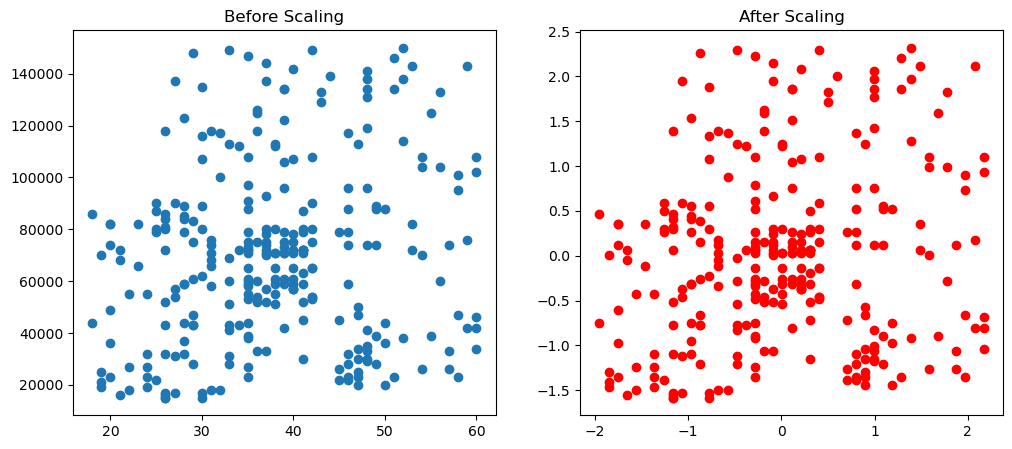

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')        
ax2.set_title("After Scaling")

##  Probability Density Function (PDF) of Unscaled and Scaled data

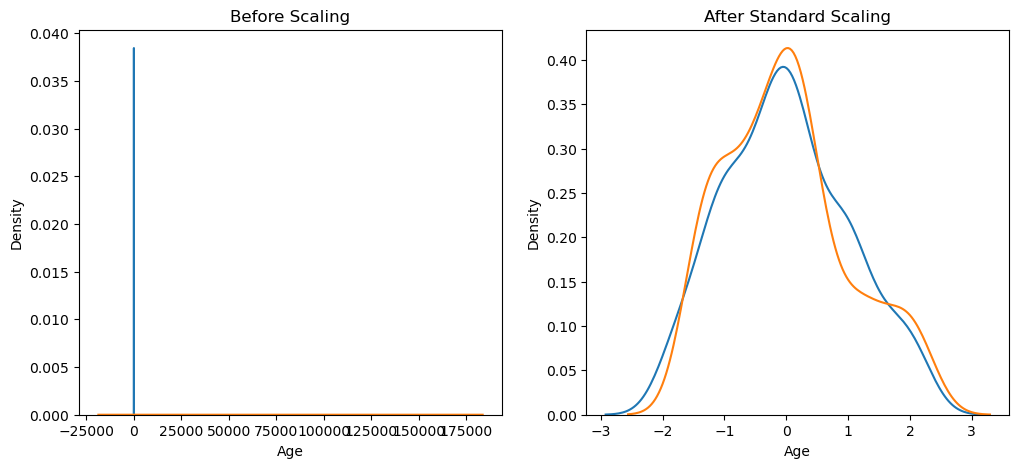

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title("After Standard Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Comparison of Distributions

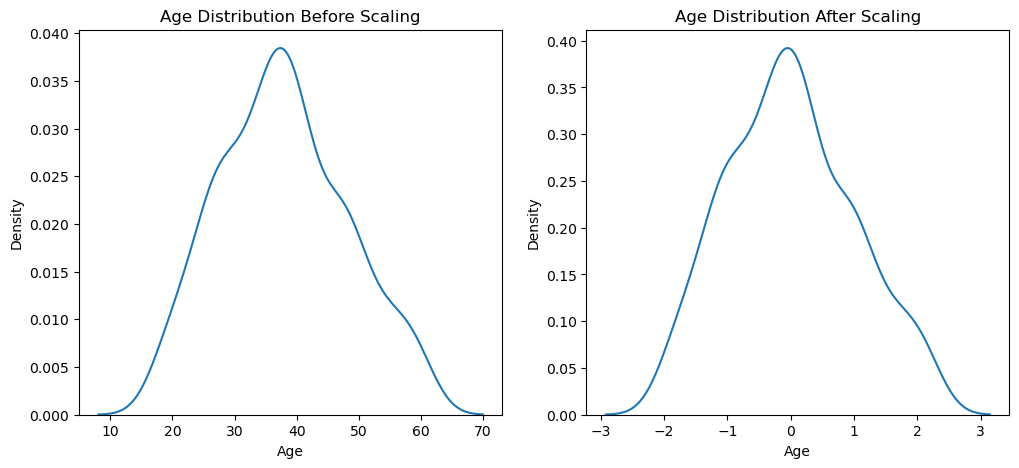

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

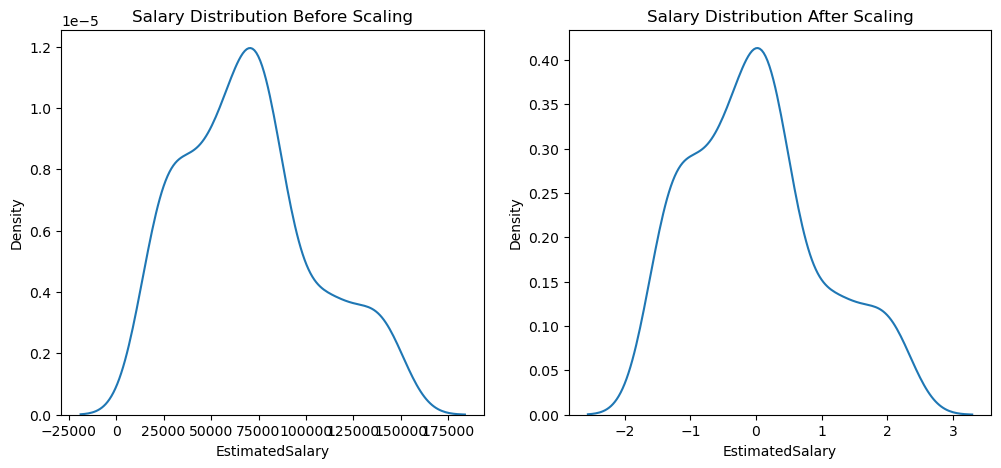

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution After Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Why Scaling is Important?

In [26]:
from sklearn.linear_model import LogisticRegression

lr_regression = LogisticRegression()
lr_scaled_regression = LogisticRegression()

In [28]:
lr_regression.fit(X_train, y_train)
lr_scaled_regression.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = lr_regression.predict(X_test)
y_pred_scaled = lr_scaled_regression.predict(X_test_scaled)

In [31]:
from sklearn.metrics import accuracy_score

In [35]:
print(f"Actual {accuracy_score(y_test, y_pred)}")
print(f"Scaled {accuracy_score(y_test, y_pred_scaled)}")

Actual 0.875
Scaled 0.8666666666666667


In [36]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
tree = DecisionTreeClassifier()
tree_scaled = DecisionTreeClassifier()

In [42]:
tree.fit(X_train, y_train)
tree_scaled.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
y_pred_tree = tree.predict(X_test)
y_pred_scaled_tree = tree_scaled.predict(X_test_scaled)

In [47]:
print(f"Actual {accuracy_score(y_test, y_pred_tree)}")
print(f"Scaled {accuracy_score(y_test, y_pred_scaled_tree)}")

Actual 0.875
Scaled 0.8666666666666667


In [48]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Effect of Outlier

To see effects of Outlier in Feature Scaling, We manually add some Outlier data in the actual data of Age and Estimated Salary. Since, our data is between Age 18-60 and EstimatedSalary 15000-150000, We add some more minimum and maximum value for creating outliers

In [49]:
df = pd.concat(
    [
        df,
        pd.DataFrame({
            'Age': [5, 90, 95],
            'EstimatedSalary': [1000, 250000, 350000],
            'Purchased': [0, 1, 1]
        })
    ],
    ignore_index=True
)

In [50]:
df.describe()

,Age,EstimatedSalary,Purchased
count,403.000000,403.000000,403.000000
mean,37.846154,70714.640199,0.359801
std,11.255343,37959.790969,0.480539
min,5.000000,1000.000000,0.000000
25%,29.500000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,95.000000,350000.000000,1.000000


In [52]:
# Let's again perform train test split
# train test split is recommended to do in the beginning to do further code
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

In [53]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [57]:
# use of describe() function in NumPy used in Original Data
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,282.0,282.0
mean,38.1,69138.3
std,11.0,35357.7
min,5.0,1000.0
25%,30.0,43000.0
50%,37.0,68000.0
75%,46.0,86750.0
max,90.0,250000.0


In [58]:
# use of describe() function in NumPy used in Original Data
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,282.0,282.0
mean,0.0,0.0
std,1.0,1.0
min,-3.0,-1.9
25%,-0.7,-0.7
50%,-0.1,-0.0
75%,0.7,0.5
max,4.7,5.1


Text(0.5, 1.0, 'After Scaling')

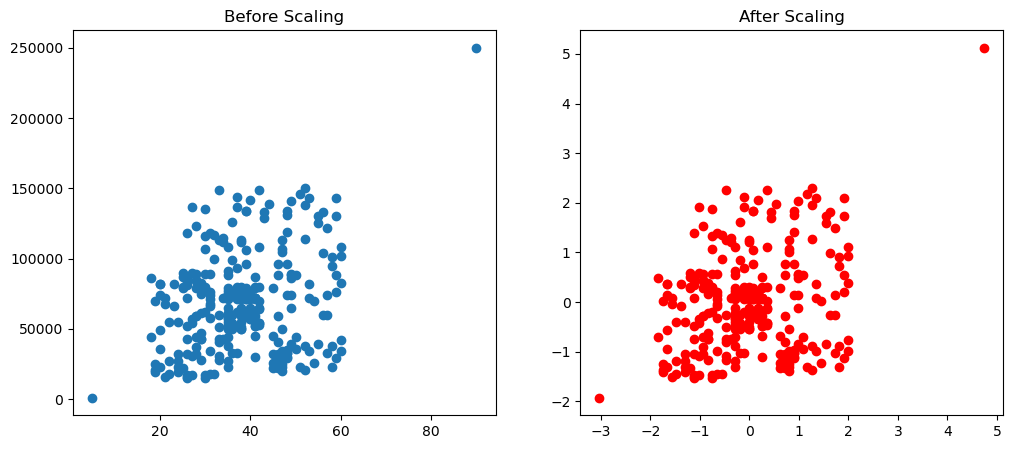

In [59]:
# Effect of Scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')        
ax2.set_title("After Scaling")

Now from this example we can conclude that, Impact of outliers still exists even after performing Data Scaling. So we must handle outliers either by removing them. So that our model can perform better and Generalize.

## Where to use Standardization?

--------------------------------------------------------------------------------------------------------------------------------------------
|Algorithm(s)                           | Reason for Applying Feature Scaling                                                              |
|------------------------------------------------------------------------------------------------------------------------------------------|
|1. K-Means                             | Use the Euclidean Distance measure                                                               |
|                                       |                                                                                                  |
|2. K-Nearest-Neighbours                | Measure the distances between pairs of samples and these distances are influenced                |
|                                       | by the measurement units                                                                         |
|                                       |                                                                                                  |
|3. Principal Component Analysis (PCA)  | Try to get the feature with maximum variance.                                                    |
|                                       |                                                                                                  |
|4. Artificial Neural Network           | Apply Gradient Descent                                                                           |
|                                       |                                                                                                  |
|5. Gradient Descent                    | Theta calculation becomes faster after feature scaling and the learning rate in the update       |  |                                       | equation of Stochastic Descent is the same from every parameter.                                 |
--------------------------------------------------------------------------------------------------------------------------------------------